# Semester Project — Estimation of Obesity Levels
## Part 1: Data Preparation & Leakage-Free Pipeline

**Group:** [Muhaimin Azeem | Naeem Akmal | Rana Fahad Ahmad]

**Course:** Introduction to Machine Learning

**Dataset:** UCI Estimation of Obesity Levels (2,111 rows, 16 features)

**Target:** NObeyesdad (7-class classification)

**Success metric:** Macro F1-score + Accuracy

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from google.colab import drive
drive.mount('/content/drive')

sns.set_style("whitegrid")
%matplotlib inline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
df = pd.read_csv("/content/drive/MyDrive/ObesityDataSet_raw_and_data_sinthetic.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (2111, 17)

Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Data types:
 Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 1. Problem Framing

- **Target variable:** `NObeyesdad` (obesity level)
- **Task type:** Multi-class classification (7 classes)
- **Success metric:** Macro F1-score (primary) and accuracy (secondary)
- **Why F1:** If classes are imbalanced, accuracy can be misleading. Macro F1 treats all classes equally.

**Why this dataset:** It has 2,111 rows (above the 1,000 minimum), a mix of numeric and categorical features, a clear multi-class target, no missing values, and supports clustering/PCA for Part 4.

In [15]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total missing: 0


In [16]:
print("Target class distribution:")
print(df['NObeyesdad'].value_counts())
print("\nProportions:")
print(df['NObeyesdad'].value_counts(normalize=True).round(3))

Target class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Proportions:
NObeyesdad
Obesity_Type_I         0.166
Obesity_Type_III       0.153
Obesity_Type_II        0.141
Overweight_Level_I     0.137
Overweight_Level_II    0.137
Normal_Weight          0.136
Insufficient_Weight    0.129
Name: proportion, dtype: float64


The dataset has no missing values, so imputation is not strictly required. However, we include SimpleImputer in the pipeline to make it robust and reproducible — a best practice.

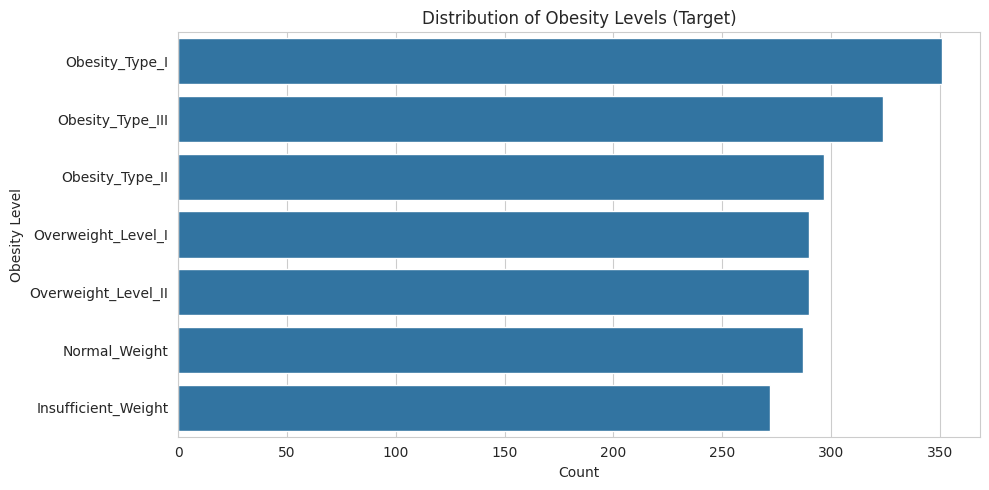

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(y='NObeyesdad', data=df, order=df['NObeyesdad'].value_counts().index)
plt.title("Distribution of Obesity Levels (Target)")
plt.xlabel("Count")
plt.ylabel("Obesity Level")
plt.tight_layout()
plt.show()